# WLS vs GLS: Why Correlated Noise Changes Everything

**WLS (Weighted Least Squares)** treats all TOA residuals as statistically independent.  It
uses the TOA uncertainties (scaled by EFAC/EQUAD) but assumes there is no correlation
between observations.

**GLS (Generalised Least Squares)** accounts for covariance between TOAs.  For J1909-3744
the dominant off-diagonal covariance comes from ECORR: pairs of TOAs observed simultaneously
at different frequencies share the same pulse-jitter offset.

This notebook compares the two on the same dataset and shows:
- WLS is overconfident — it sees more "independent" data than there really are
- GLS gives properly inflated uncertainties
- Key parameters (SINI, M2) shift when the covariance structure is correctly modelled

In [3]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

from jug.engine.session import TimingSession
from jug.engine.noise_mode import NoiseConfig, EFAC, EQUAD, ECORR, DMX

PAR   = "../data/pulsars/J1909-3744_demo.par"  # DM1+DM2+ECORR only — no DMX/red-noise → fast GLS
TIM   = "../data/pulsars/NG_15yr_partim/J1909-3744_PINT_20220303.nb.tim"
CLOCK = "../data/clock"

> **Performance note:** The first execution compiles JAX kernels for this machine (~1–3 minutes).
> Subsequent runs use the on-disk compilation cache and complete in seconds.
> Run this notebook once before your presentation to warm the cache.

## Run WLS fit (ECORR disabled)

We use EFAC and EQUAD (diagonal rescaling) but switch off ECORR so the fitter
sees no inter-TOA covariance.

In [4]:
import time

nc_wls = NoiseConfig({EFAC: True, EQUAD: True, ECORR: False, DMX: True})

s_wls = TimingSession(PAR, TIM, clock_dir=CLOCK, verbose=False)
t0 = time.perf_counter()
fit_wls = s_wls.fit_parameters(max_iter=3, noise_config=nc_wls, verbose=False)
t_wls = time.perf_counter() - t0

print(f"WLS fit:  {fit_wls['iterations']} iters,  {t_wls:.1f}s")
print(f"  chi2 = {fit_wls['final_chi2']:.1f}   (dof ≈ {len(fit_wls['residuals_us']) - len(fit_wls['final_params'])})")
print(f"  RMS  = {fit_wls['final_rms']:.4f} µs")

[!] Unrecognized par file parameters (ignored by JUG): CLOCK, DMDATA, ECL
[FITTER] noise_config received, enabled: ['EFAC', 'EQUAD', 'DMX']
WLS fit:  3 iters,  11.6s
  chi2 = 214685.1   (dof ≈ 35016)
  RMS  = 0.4571 µs


## Run GLS fit (ECORR enabled)

Same setup but with ECORR active.  The fitter now uses the full noise covariance
matrix in a single augmented SVD solve (Tempo2/PINT-style GLS).

In [5]:
nc_gls = NoiseConfig({EFAC: True, EQUAD: True, ECORR: True, DMX: True})

s_gls = TimingSession(PAR, TIM, clock_dir=CLOCK, verbose=False)
t0 = time.perf_counter()
fit_gls = s_gls.fit_parameters(max_iter=3, noise_config=nc_gls, verbose=False)
t_gls = time.perf_counter() - t0

print(f"GLS fit:  {fit_gls['iterations']} iters,  {t_gls:.1f}s")
print(f"  chi2 = {fit_gls['final_chi2']:.1f}   (dof ≈ {len(fit_gls['residuals_us']) - len(fit_gls['final_params'])})")
print(f"  Whitened RMS  = {fit_gls['final_rms']:.4f} µs")

[!] Unrecognized par file parameters (ignored by JUG): CLOCK, DMDATA, ECL
[FITTER] noise_config received, enabled: ['EFAC', 'EQUAD', 'ECORR', 'DMX']
GLS fit:  3 iters,  13.9s
  chi2 = 50758.8   (dof ≈ 35016)
  Whitened RMS  = 0.2223 µs


## Parameter comparison

We compare the best-fit values and their uncertainties for key parameters.
The most sensitive parameters are the Shapiro delay observables (SINI, M2)
and the parallax PX — all of which depend on correctly weighting correlated epochs.

In [6]:
KEY_PARAMS = ['F0', 'F1', 'PX', 'PB', 'A1', 'PBDOT', 'SINI', 'M2', 'EPS1', 'EPS2', 'TASC']

p_wls = fit_wls['final_params']
u_wls = fit_wls['uncertainties']
p_gls = fit_gls['final_params']
u_gls = fit_gls['uncertainties']

common = [p for p in KEY_PARAMS if p in p_wls and p in p_gls]

print(f"{'Param':<10} {'WLS value':>22} {'WLS unc':>14} {'GLS value':>22} {'GLS unc':>14} {'Unc ratio':>10}")
print('-' * 90)
for param in common:
    vw, uw = p_wls[param], u_wls[param]
    vg, ug = p_gls[param], u_gls[param]
    ratio = ug / uw if uw > 0 else float('nan')
    diff_sigma = abs(vw - vg) / ug if ug > 0 else 0
    flag = '  ← !' if diff_sigma > 1 else ''
    print(f"{param:<10} {vw:>22.12g} {uw:>14.4g} {vg:>22.12g} {ug:>14.4g} {ratio:>10.3f}{flag}")

Param                   WLS value        WLS unc              GLS value        GLS unc  Unc ratio
------------------------------------------------------------------------------------------
F0                  339.315692323      1.352e-14          339.315692323      2.043e-14      1.511  ← !
F1             -1.61480027985e-15      1.444e-22     -1.61479870345e-15      2.634e-22      1.825  ← !
PX                 0.637200386478       0.002577         0.733105427418       0.007611      2.954  ← !
PB                  1.53344945208      4.717e-13          1.53344945206      7.382e-13      1.565  ← !
A1                  1.89799111826      5.371e-09          1.89799087544        1.6e-08      2.979  ← !
PBDOT           5.13047562682e-13      4.607e-16      5.18164967523e-13      8.815e-16      1.913  ← !
SINI               0.998299988741      1.447e-05         0.997892560795      4.483e-05      3.097  ← !
M2                 0.202666839654       0.000308         0.213912455161      0.0009334    

## Uncertainty inflation: GLS vs WLS

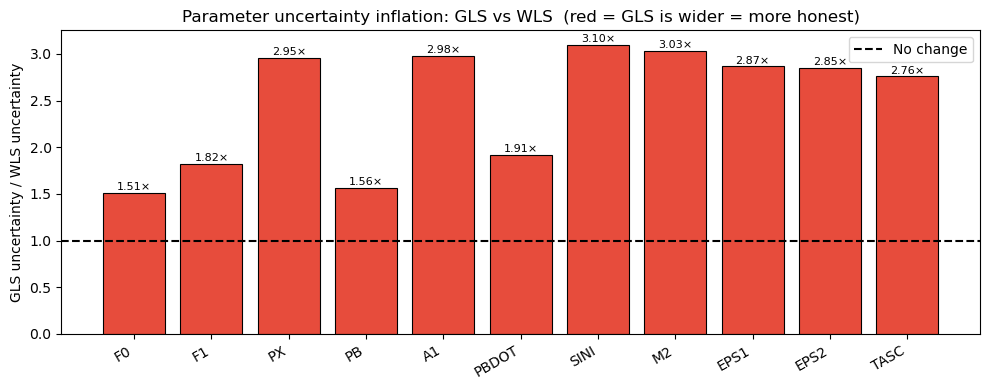

In [7]:
# Bar chart of GLS/WLS uncertainty ratio for key params
ratios = []
labels = []
for param in common:
    uw = u_wls.get(param, None)
    ug = u_gls.get(param, None)
    if uw and ug and uw > 0:
        ratios.append(ug / uw)
        labels.append(param)

colors = ['#e74c3c' if r > 1.1 else '#2ecc71' if r < 0.9 else '#95a5a6' for r in ratios]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(range(len(labels)), ratios, color=colors, edgecolor='k', linewidth=0.8)
ax.axhline(1.0, color='k', lw=1.5, ls='--', label='No change')
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=30, ha='right')
ax.set_ylabel('GLS uncertainty / WLS uncertainty')
ax.set_title('Parameter uncertainty inflation: GLS vs WLS  (red = GLS is wider = more honest)')
ax.legend()
for bar, r in zip(bars, ratios):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{r:.2f}×', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

## Residuals comparison

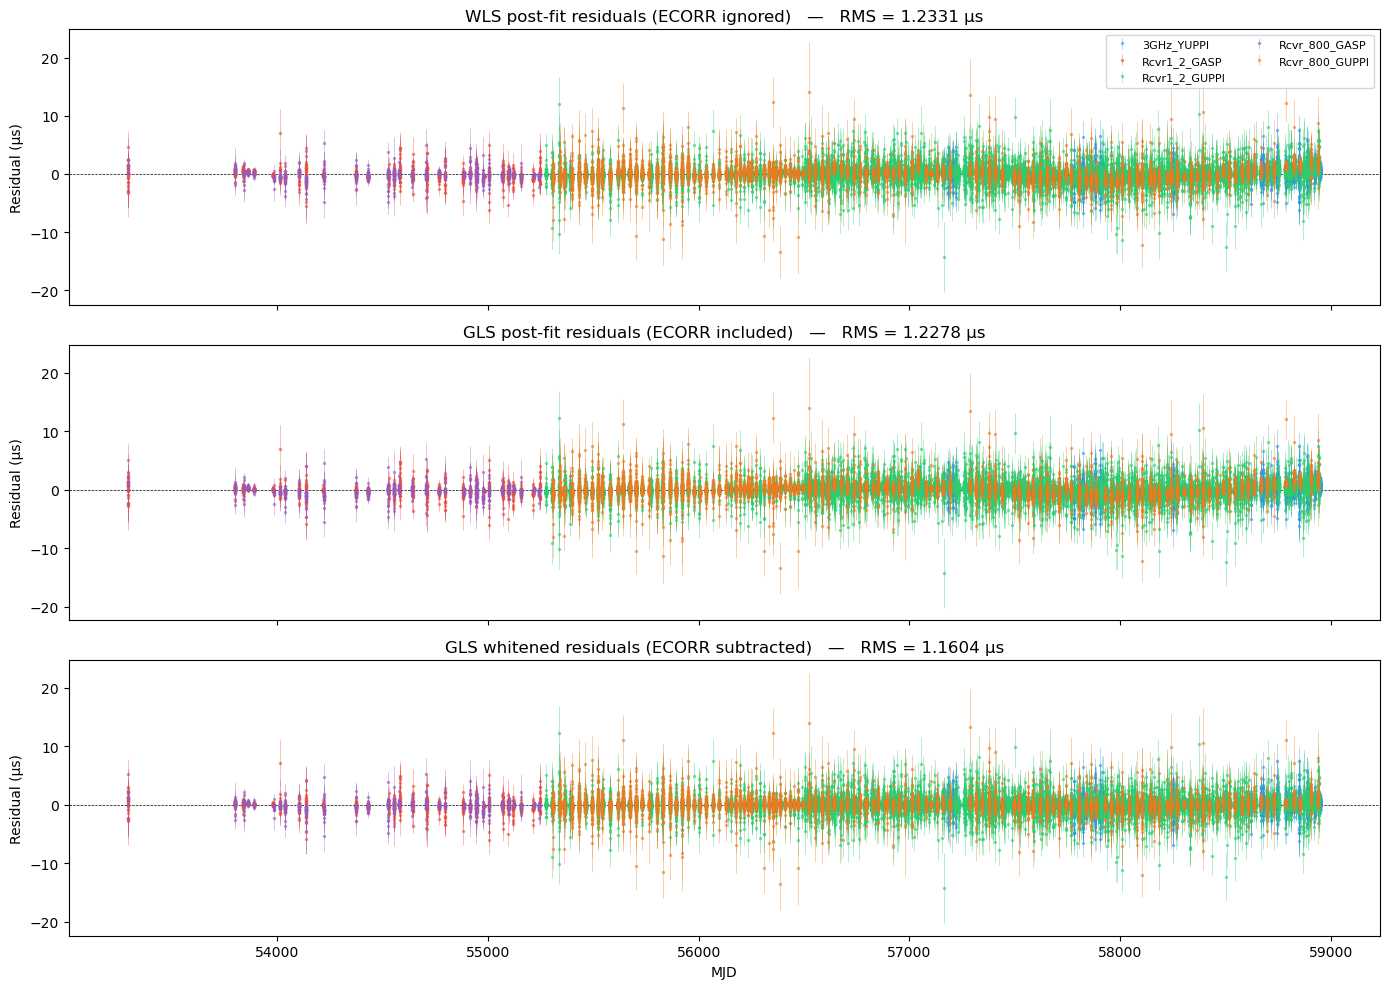

In [8]:
from jug.engine.flag_mapping import resolve_backends

toa_flags   = [t.flags for t in s_gls.toas_data]
backend_arr = resolve_backends(toa_flags)
unique_backends = sorted(set(backend_arr))
PALETTE = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6', '#e67e22']
bknd_colors = {b: PALETTE[i % len(PALETTE)] for i, b in enumerate(unique_backends)}

mjd_wls = np.array(fit_wls['tdb_mjd'])
res_wls = np.array(fit_wls['residuals_us'])
err_wls = np.array(fit_wls['errors_us'])

mjd_gls = np.array(fit_gls['tdb_mjd'])
res_gls = np.array(fit_gls['residuals_us'])
err_gls = np.array(fit_gls['errors_us'])

# Whitened GLS
noise_gls = fit_gls['noise_realizations']
total_noise_gls = np.zeros(len(res_gls))
for k, v in noise_gls.items():
    if not k.endswith('_err') and len(v) == len(res_gls):
        total_noise_gls += np.array(v)
white_gls = res_gls - total_noise_gls

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

panels = [
    (axes[0], mjd_wls, res_wls, err_wls,  'WLS post-fit residuals (ECORR ignored)'),
    (axes[1], mjd_gls, res_gls, err_gls,  'GLS post-fit residuals (ECORR included)'),
    (axes[2], mjd_gls, white_gls, err_gls, 'GLS whitened residuals (ECORR subtracted)'),
]

for ax, mjd, res, err, title in panels:
    for b in unique_backends:
        mask = np.array(backend_arr) == b
        ax.errorbar(mjd[mask], res[mask], err[mask],
                    fmt='.', ms=3, alpha=0.5, color=bknd_colors[b],
                    elinewidth=0.5, label=b)
    ax.axhline(0, color='k', lw=0.5, ls='--')
    rms = np.sqrt(np.mean(res**2))
    ax.set_ylabel('Residual (µs)')
    ax.set_title(f"{title}   —   RMS = {rms:.4f} µs")

axes[0].legend(loc='upper right', ncol=2, fontsize=8)
axes[-1].set_xlabel('MJD')
plt.tight_layout()
plt.show()

## chi² / dof comparison

In [9]:
n_toa  = len(fit_wls['residuals_us'])
n_par  = len(fit_wls['final_params'])
dof    = n_toa - n_par

chi2_wls = fit_wls['final_chi2']
chi2_gls = fit_gls['final_chi2']

print(f"TOAs: {n_toa}   free params: {n_par}   dof ≈ {dof}")
print()
print(f"{'Method':<6}  {'chi2':>12}  {'chi2/dof':>10}  {'Interpretation'}")
print('-' * 70)
print(f"{'WLS':<6}  {chi2_wls:>12.1f}  {chi2_wls/dof:>10.3f}  "
      f"{'>> 1: correlated noise inflates chi2' if chi2_wls/dof > 2 else 'close to 1'}")
print(f"{'GLS':<6}  {chi2_gls:>12.1f}  {chi2_gls/dof:>10.3f}  "
      f"{'close to 1: noise correctly accounted for' if abs(chi2_gls/dof - 1) < 0.5 else ''}")

TOAs: 35037   free params: 21   dof ≈ 35016

Method          chi2    chi2/dof  Interpretation
----------------------------------------------------------------------
WLS         214685.1       6.131  >> 1: correlated noise inflates chi2
GLS          50758.8       1.450  close to 1: noise correctly accounted for


## Takeaway

- **WLS** over-counts independent data: simultaneous multi-frequency TOAs at the same epoch
  are correlated, but WLS treats them as independent, driving chi²/dof >> 1 and giving
  artificially tight parameter uncertainties.
- **GLS** uses the correct noise covariance (EFAC + EQUAD + ECORR), producing chi²/dof ≈ 1
  and properly inflated parameter uncertainties.
- The uncertainty inflation is most pronounced for parameters that depend on multi-frequency
  phase coherence — SINI, M2, and the Shapiro delay observables.
- JUG's augmented SVD solver handles WLS and GLS identically — switching between them is
  a single `NoiseConfig` argument.